# 🏷️ Week 5 Flipped Learning Lab: CRF-based Named Entity Recognition

**Course:** Probabilistic Graphical Models (ISW3005-41)

**Instructor:** Prof. Hogun Park

**Topic:** Undirected Graphical Models — NER with Conditional Random Fields

**Deliverables:** This Notebook (.ipynb) + 5-min presentation (in the next class)

**Estimated time:** ~60 minutes

---

### 📝 Group Information (fill in below)

- Student Names:

2021313549 정성수

2021313129 박태준​

2022310668 김동건​

2025313590 황일명

## 0. Learning Objectives

In this lab, you will experience how the core concepts from **Chapter 4 (Undirected Graphical Models)** operate in a real NLP task.

| Concept (Chapter 4) | Corresponding Element in This Lab |
|---|---|
| Feature function $f_k$ in log-linear models (Def. 4.15) | Design your own feature functions for NER |
| Partition function $Z(\mathbf{X})$ (Def. 4.18) | Observe automatic normalization during CRF training |
| Pairwise factor $\phi(Y_t, Y_{t+1})$ (Box 4.E) | Visualize and interpret the learned label transition matrix |
| Compatibility / affinity between variable assignments (Sec. 4.1) | Analyze which feature–label combinations receive highest weights |

**Key equation — CRF conditional distribution (Def. 4.18, Box 4.E):**

$$P(\mathbf{Y} \mid \mathbf{X}) = \frac{1}{Z(\mathbf{X})} \exp\left(-\sum_k w_k f_k(\mathbf{Y}, \mathbf{X})\right)$$

**What you will design in this lab is the feature function $f_k$ itself.** The CRF learns only the weights $w_k$ from data; the features are hand-crafted by you.


## 1. Environment Setup

Run the cell below to install and import all required libraries.


In [ ]:
# ============================================================
# Library installation (Colab)
# ============================================================
!pip install -q sklearn-crfsuite seqeval datasets

import warnings
warnings.filterwarnings('ignore')

import sklearn_crfsuite
from seqeval.metrics import classification_report, f1_score
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

print("✅ All libraries installed and imported successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00
✅ All libraries installed and imported successfully.


## 2. Dataset

### 2.1 About CoNLL-2003

We use the **CoNLL-2003 Shared Task** English NER dataset, one of the most widely used benchmarks in Named Entity Recognition. The data comes from Reuters news articles.

**Data structure:** Each sentence consists of tokens, each annotated with a POS tag and an NER tag.

| Field | Description | Example |
|-------|-------------|---------|
| `word` | Original token | `London`, `said`, `2002` |
| `POS tag` | Part-of-speech (Penn Treebank) | `NNP` (proper noun), `VBD` (past tense verb), `CD` (number) |
| `NER tag` | Named Entity tag in BIO format | `B-LOC`, `O`, `O` |

### 2.2 POS Tag Reference (Penn Treebank)

Since POS tags are an important feature for NER, here is a reference for the most common tags:

| POS | Meaning | Example | Relevance to NER |
|-----|---------|---------|-----------------|
| `NNP` | Proper noun, singular | *London*, *John*, *Microsoft* | **Strongest entity signal** — most entities are proper nouns |
| `NNPS` | Proper noun, plural | *Americans*, *Olympics* | Often `MISC` or `ORG` entities |
| `NN` | Common noun, singular | *company*, *game*, *year* | Usually `O`, but some ORGs look like common nouns |
| `NNS` | Common noun, plural | *companies*, *points* | Almost always `O` |
| `CD` | Cardinal number | *3*, *1998*, *two* | Scores, dates — may be part of `MISC` entities |
| `JJ` | Adjective | *European*, *new*, *big* | `MISC` entities (nationalities, adjective-form entities) |
| `VBD` | Verb, past tense | *said*, *won*, *scored* | Almost always `O`; useful as context ("X *said*" → X is `PER`) |
| `IN` | Preposition | *in*, *of*, *at* | Always `O`; useful context ("*in* London" → next word is `LOC`) |
| `DT` | Determiner | *the*, *a*, *an* | Always `O` |
| `POS` | Possessive ending | *'s* | Always `O` |

### 2.3 BIO Tagging Scheme (Box 4.E)

BIO notation disambiguates entity boundaries — especially when two entities of the same type are adjacent.

| Tag | Meaning | Example |
|-----|---------|---------|
| `B-PER` | **Beginning** of a Person name | **[B-PER]** John **[I-PER]** Smith |
| `I-PER` | **Inside** (continuation) of a Person name | |
| `B-LOC` | Beginning of a Location | **[B-LOC]** New **[I-LOC]** York |
| `B-ORG` | Beginning of an Organization | **[B-ORG]** European **[I-ORG]** Union |
| `B-MISC` | Beginning of a Miscellaneous entity | **[B-MISC]** World **[I-MISC]** Cup |
| `I-*` | Inside / continuation of the corresponding entity | |
| `O` | **Outside** — not an entity | *the*, *said*, *in* |

**Why BIO?** Without the B/I distinction, adjacent entities of the same type cannot be separated. This boundary information is exactly what the **transition factor** $\phi(Y_t, Y_{t+1})$ in a linear-chain CRF learns: `B-PER → I-PER` gets a high weight, while `B-PER → I-LOC` gets a very low weight.


In [ ]:
# ============================================================
# Download and load CoNLL-2003 English NER data
# ============================================================
from datasets import load_dataset

# The original 'conll2003' uses a legacy script that newer versions of
# the datasets library no longer support. We try multiple alternatives.
try:
    # Option 1: BramVanroy's Parquet re-publish (most reliable)
    dataset = load_dataset("BramVanroy/conll2003")
    print("✅ Loaded from BramVanroy/conll2003")
except Exception:
    try:
        # Option 2: eriktks with parquet branch
        dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
        print("✅ Loaded from eriktks/conll2003 (parquet branch)")
    except Exception:
        # Option 3: pin datasets library version and use trust_remote_code
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets==3.6.0"])
        dataset = load_dataset("conll2003", trust_remote_code=True)
        print("✅ Loaded conll2003 with datasets==3.6.0")

# NER tag mapping
ner_tags = dataset["train"].features["ner_tags"].feature.names
pos_tags = dataset["train"].features["pos_tags"].feature.names

print("NER tags:", ner_tags)
print("POS tags:", pos_tags)
print()

# Convert HuggingFace format → list of [(word, POS, NER), ...] sentences
def convert_to_tuples(split):
    sentences = []
    for example in split:
        sent = []
        for w, p, n in zip(example["tokens"], example["pos_tags"], example["ner_tags"]):
            sent.append((w, pos_tags[p], ner_tags[n]))
        sentences.append(sent)
    return sentences

train_sents = convert_to_tuples(dataset["train"])
test_sents  = convert_to_tuples(dataset["test"])

print(f"📊 Dataset Statistics")
print(f"   Train: {len(train_sents):,} sentences, {sum(len(s) for s in train_sents):,} tokens")
print(f"   Test:  {len(test_sents):,} sentences, {sum(len(s) for s in test_sents):,} tokens")
print()

# Show a sample sentence that contains entities
sample_sent = next(s for s in train_sents if any(l != 'O' for _, _, l in s) and len(s) <= 15)
print("📝 Sample sentence (with entities):")
print(f"   Raw: {' '.join(w for w, _, _ in sample_sent)}")
print()
print(f"   {'Token':20s} {'POS':8s} {'NER':10s}  Note")
print(f"   {'-'*20} {'-'*8} {'-'*10}  {'-'*20}")
for word, pos, ner in sample_sent:
    note = ''
    if ner.startswith('B-'): note = '← entity begins'
    elif ner.startswith('I-'): note = '← entity continues'
    print(f"   {word:20s} {pos:8s} {ner:10s}  {note}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/310k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

✅ Loaded from BramVanroy/conll2003
NER tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
POS tags: ['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']

📊 Dataset Statistics
   Train: 14,041 sentences, 203,621 tokens
   Test:  3,453 sentences, 46,435 tokens

📝 Sample sentence (with entities):
   Raw: EU rejects German call to boycott British lamb .

   Token                POS      NER         Note
   -------------------- -------- ----------  --------------------
   EU                   NNP      B-ORG       ← entity begins
   rejects              VBZ      O           
   German               JJ       B-MISC      ← entity begins
   call                 NN       O           
   to                   TO       O

In [ ]:
# ============================================================
# Label distribution
# ============================================================
all_labels = [label for sent in train_sents for _, _, label in sent]
label_counts = Counter(all_labels)

print("📊 NER Tag Distribution (Train):")
for label, count in label_counts.most_common():
    pct = count / len(all_labels) * 100
    bar = '█' * int(pct / 2)
    print(f"   {label:8s}: {count:7,} ({pct:5.1f}%) {bar}")

n_entity = sum(c for l, c in label_counts.items() if l != 'O')
print(f"\n   Entity tokens: {n_entity:,} ({n_entity/len(all_labels)*100:.1f}%)")
print(f"   O tokens:      {label_counts['O']:,} ({label_counts['O']/len(all_labels)*100:.1f}%)")
print(f"   → Note the severe class imbalance. The vast majority of tokens are O.")


📊 NER Tag Distribution (Train):
   O       : 169,578 ( 83.3%) █████████████████████████████████████████
   B-LOC   :   7,140 (  3.5%) █
   B-PER   :   6,600 (  3.2%) █
   B-ORG   :   6,321 (  3.1%) █
   I-PER   :   4,528 (  2.2%) █
   I-ORG   :   3,704 (  1.8%) 
   B-MISC  :   3,438 (  1.7%) 
   I-LOC   :   1,157 (  0.6%) 
   I-MISC  :   1,155 (  0.6%) 

   Entity tokens: 34,043 (16.7%)
   O tokens:      169,578 (83.3%)
   → Note the severe class imbalance. The vast majority of tokens are O.


## 3. Utility Functions

Helper functions used throughout the lab for feature extraction, training, and evaluation.


In [ ]:
# ============================================================
# Common utilities
# ============================================================
def sent2features(sent, feature_func):
    """Apply feature_func to each token in a sentence."""
    return [feature_func(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    """Extract NER labels from a sentence."""
    return [label for _, _, label in sent]

def train_and_evaluate(feature_func, train_data, test_data,
                       c1=0.1, c2=0.1, verbose=True):
    """
    Train a CRF with the given feature function and evaluate on test data.
    Returns: (crf_model, y_pred, overall_f1_score)
    """
    X_train = [sent2features(s, feature_func) for s in train_data]
    y_train = [sent2labels(s) for s in train_data]
    X_test  = [sent2features(s, feature_func) for s in test_data]
    y_test  = [sent2labels(s) for s in test_data]

    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=100,
        all_possible_transitions=True
    )
    crf.fit(X_train, y_train)
    y_pred = crf.predict(X_test)

    score = f1_score(y_test, y_pred)

    if verbose:
        print(classification_report(y_test, y_pred, digits=4))

    return crf, y_pred, score

def compare_predictions(sent, y_true, y_pred, n=None):
    """Side-by-side comparison of true vs predicted labels."""
    tokens = [w for w, _, _ in sent]
    if n:
        tokens, y_true, y_pred = tokens[:n], y_true[:n], y_pred[:n]

    print(f"{'Token':20s} {'True':12s} {'Pred':12s} {'':5s}")
    print("-" * 52)
    for tok, true, pred in zip(tokens, y_true, y_pred):
        match = "✅" if true == pred else "❌"
        print(f"{tok:20s} {true:12s} {pred:12s} {match}")

print("✅ Utility functions ready.")


✅ Utility functions ready.


---

## Part 1: Baseline CRF (50 points)

### 1.1 Baseline Feature Function

Below is a basic feature extractor. **Read and understand each feature** before running.

In the CRF's log-linear formulation (Def. 4.15), each feature function $f_k(\mathbf{D}_k)$ captures how *compatible* a particular input pattern is with a particular label. During training, the model learns a weight $w_k$ for each feature: a large positive weight means that feature strongly supports the associated label.

The table below explains every baseline feature and its role in NER:

| Feature | Example Value | Role in NER |
|---------|--------------|-------------|
| `bias` | always `1.0` | Learns the base frequency (prior) of each label. Since `O` is dominant, the bias weight for `O` will be large. |
| `word.lower()` | `"london"` | Direct word–entity mapping. E.g., `"london"` → `LOC`, `"microsoft"` → `ORG`. |
| `word[-3:]` | `"don"` | 3-char suffix. English suffixes like `-land`, `-ton` suggest locations; `-son`, `-ski` suggest person names. |
| `word[-2:]` | `"on"` | 2-char suffix. Shorter, more generalizable patterns. |
| `word.isupper()` | `True/False` | All-caps words (e.g., `"NATO"`, `"EU"`, `"USA"`) → abbreviations, often `ORG` or `LOC`. |
| `word.istitle()` | `True/False` | Title case (e.g., `"London"`, `"Smith"`) — the **strongest single signal** for entities. Less reliable at sentence start. |
| `word.isdigit()` | `True/False` | Numbers (e.g., `"2002"`, `"15"`) — usually `O`, but may be part of scores or dates (`MISC`). |
| `postag` | `"NNP"`, `"VBD"` | POS tag. `NNP` (proper noun) strongly predicts entity. `IN` (preposition), `DT` (determiner) → almost always `O`. |
| `postag[:2]` | `"NN"`, `"VB"` | Coarser POS category. Groups `NNP/NNPS/NN/NNS` into `NN`, `VBD/VBZ/VBG` into `VB`. |
| `-1:word.lower()` | prev word | Context: prev word `"mr."`, `"president"` → next word is likely `PER`. |
| `-1:word.istitle()` | `True/False` | Prev word title-cased → may be inside a multi-word entity (`I-*`). |
| `-1:postag` | prev POS | Preposition `IN` before a title-cased word → likely `LOC` (e.g., `"in London"`). |
| `+1:word.lower()` | next word | Context: next word `"said"`, `"announced"` → current word is `PER`. |
| `+1:word.istitle()` | `True/False` | Next word also capitalized → current may be start of multi-word entity (`B-*`). |
| `+1:postag` | next POS | Next POS is verb → current word is likely the last token of an entity. |
| `BOS` | sentence start | First word is always capitalized — tells the model `istitle()` is less reliable here. |
| `EOS` | sentence end | Last token (usually punctuation) gets special handling. |

**Key observation:** These features fall into three categories:
1. **Intrinsic properties** of the current word (`word.lower()`, `istitle()`, `postag`) — "what is this word?"
2. **Context** from neighboring words (`-1:*`, `+1:*`) — "what surrounds it?"
3. **Position** markers (`BOS`, `EOS`) — "where in the sentence?"

All of these are **node (emission) features** corresponding to $\phi^2_t(Y_t, \mathbf{X})$ in Box 4.E. The CRF also automatically learns **edge (transition) features** $\phi^1_t(Y_t, Y_{t+1})$ thanks to the `all_possible_transitions=True` setting.


In [ ]:
# ============================================================
# Baseline Feature Function
# ============================================================
def word2features_baseline(sent, i):
    """
    Baseline feature extractor.
    sent: [(word, POS, NER_tag), ...] sentence
    i:    index of current token
    Returns: dict (feature_name -> feature_value)
    """
    word = sent[i][0]
    postag = sent[i][1]

    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],           # 3-char suffix
        'word[-2:]': word[-2:],           # 2-char suffix
        'word.isupper()': word.isupper(), # all uppercase?
        'word.istitle()': word.istitle(), # title case?
        'word.isdigit()': word.isdigit(), # digit?
        'postag': postag,
        'postag[:2]': postag[:2],
    }

    # Previous word (i > 0)
    if i > 0:
        word_prev = sent[i-1][0]
        postag_prev = sent[i-1][1]
        features.update({
            '-1:word.lower()': word_prev.lower(),
            '-1:word.istitle()': word_prev.istitle(),
            '-1:postag': postag_prev,
        })
    else:
        features['BOS'] = True   # Beginning of Sentence

    # Next word (i < len-1)
    if i < len(sent) - 1:
        word_next = sent[i+1][0]
        postag_next = sent[i+1][1]
        features.update({
            '+1:word.lower()': word_next.lower(),
            '+1:word.istitle()': word_next.istitle(),
            '+1:postag': postag_next,
        })
    else:
        features['EOS'] = True   # End of Sentence

    return features

# Inspect: show features for a sample token
sample_sent_idx = next(i for i, s in enumerate(train_sents)
                       if any(l != 'O' for _, _, l in s) and len(s) <= 12)
sample = train_sents[sample_sent_idx]
print(f"📝 Sample sentence: {' '.join(w for w,_,_ in sample)}")
print(f"   Extracting features for token index 1: '{sample[1][0]}' ({sample[1][1]}, {sample[1][2]})\n")

sample_features = word2features_baseline(sample, 1)
for k, v in sorted(sample_features.items()):
    print(f"   {k:25s} = {v}")
print(f"\n   Total features per token: {len(sample_features)}")


📝 Sample sentence: EU rejects German call to boycott British lamb .
   Extracting features for token index 1: 'rejects' (VBZ, O)

   +1:postag                 = JJ
   +1:word.istitle()         = True
   +1:word.lower()           = german
   -1:postag                 = NNP
   -1:word.istitle()         = False
   -1:word.lower()           = eu
   bias                      = 1.0
   postag                    = VBZ
   postag[:2]                = VB
   word.isdigit()            = False
   word.istitle()            = False
   word.isupper()            = False
   word.lower()              = rejects
   word[-2:]                 = ts
   word[-3:]                 = cts

   Total features per token: 15


### 1.2 Train and Evaluate the Baseline

Let's train the CRF with baseline features and measure performance.


In [ ]:
# ============================================================
# Baseline training and evaluation
# ============================================================
print("🚀 Training Baseline CRF (this may take 1-2 minutes)...")
print("=" * 60)

crf_baseline, y_pred_baseline, f1_baseline = train_and_evaluate(
    word2features_baseline, train_sents, test_sents
)

print("=" * 60)
print(f"\n📊 Baseline Overall F1: {f1_baseline:.4f}")


🚀 Training Baseline CRF (this may take 1-2 minutes)...
              precision    recall  f1-score   support

         LOC     0.8428    0.8034    0.8226      1668
        MISC     0.7917    0.7365    0.7631       702
         ORG     0.7282    0.6887    0.7079      1661
         PER     0.8258    0.8472    0.8364      1617

   micro avg     0.7986    0.7739    0.7861      5648
   macro avg     0.7971    0.7690    0.7825      5648
weighted avg     0.7979    0.7739    0.7854      5648


📊 Baseline Overall F1: 0.7861


### 1.3 Baseline Result Analysis

Now let's examine the predictions in detail. This analysis serves two purposes:

1. **Identify strengths and weaknesses** — this directly informs which features to add in Part 2.
2. **Build intuition for how CRFs work** — a single feature may suggest one label, but the product of all factors (including transitions) determines the final prediction. This is analogous to Example 4.2 in the textbook, where the marginal over $(A, B)$ disagrees with the individual factor $\phi_1(A, B)$ because other factors dominate.


In [ ]:
# ============================================================
# Prediction samples (sentences containing entities)
# ============================================================
y_test_all = [sent2labels(s) for s in test_sents]

entity_sent_indices = [
    i for i, s in enumerate(test_sents)
    if any(label != 'O' for _, _, label in s) and 5 <= len(s) <= 20
]

print("📝 Prediction Samples (short sentences with entities):\n")
for idx in entity_sent_indices[:2]:
    print(f"--- Sentence #{idx} ---")
    compare_predictions(test_sents[idx], y_test_all[idx], y_pred_baseline[idx])

    errors = sum(1 for t, p in zip(y_test_all[idx], y_pred_baseline[idx]) if t != p)
    if errors == 0:
        print(f"→ All correct! ✅")
    else:
        print(f"→ {errors} error(s) in this sentence ❌")
    print()


📝 Prediction Samples (short sentences with entities):

--- Sentence #0 ---
Token                True         Pred              
----------------------------------------------------
SOCCER               O            O            ✅
-                    O            O            ✅
JAPAN                B-LOC        B-LOC        ✅
GET                  O            O            ✅
LUCKY                O            B-ORG        ❌
WIN                  O            O            ✅
,                    O            O            ✅
CHINA                B-PER        B-LOC        ❌
IN                   O            O            ✅
SURPRISE             O            O            ✅
DEFEAT               O            O            ✅
.                    O            O            ✅
→ 2 error(s) in this sentence ❌

--- Sentence #2 ---
Token                True         Pred              
----------------------------------------------------
AL-AIN               B-LOC        B-LOC        ✅
,                    O 

In [ ]:
# ============================================================
# Error pattern analysis
# ============================================================
error_types = Counter()
for sent_true, sent_pred in zip(y_test_all, y_pred_baseline):
    for true, pred in zip(sent_true, sent_pred):
        if true != pred:
            error_types[(true, pred)] += 1

print("📊 Top 10 Error Patterns (True → Predicted):\n")
for (true, pred), count in error_types.most_common(10):
    print(f"   {true:12s} → {pred:12s} : {count:5d}")

# Summarize error categories
print("\n" + "=" * 60)
print("📊 Error Category Summary:\n")

fn = sum(c for (t, p), c in error_types.items() if t != 'O' and p == 'O')
fp = sum(c for (t, p), c in error_types.items() if t == 'O' and p != 'O')
tc = sum(c for (t, p), c in error_types.items() if t != 'O' and p != 'O' and t != p)

print(f"   False Negative (entity → O, missed entities):      {fn:5d}")
print(f"   False Positive (O → entity, spurious entities):    {fp:5d}")
print(f"   Type Confusion (wrong entity type):                {tc:5d}")

# Per-entity miss rate
print("\n📊 Per-Entity Miss Rate (entity tokens predicted as O):")
for etype in ['PER', 'LOC', 'ORG', 'MISC']:
    missed = sum(c for (t, p), c in error_types.items() if etype in t and p == 'O')
    total_true = sum(1 for s in y_test_all for l in s if etype in l)
    if total_true > 0:
        print(f"   {etype:5s}: {missed:4d} / {total_true:5d} tokens missed ({missed/total_true*100:.1f}%)")


📊 Top 10 Error Patterns (True → Predicted):

   B-LOC        → B-ORG        :   163
   B-ORG        → B-PER        :   146
   O            → I-ORG        :   145
   B-ORG        → B-LOC        :   128
   B-ORG        → O            :   119
   B-MISC       → O            :    88
   B-PER        → O            :    84
   O            → B-ORG        :    82
   I-ORG        → I-PER        :    79
   B-PER        → B-ORG        :    66

📊 Error Category Summary:

   False Negative (entity → O, missed entities):        466
   False Positive (O → entity, spurious entities):      417
   Type Confusion (wrong entity type):                 1167

📊 Per-Entity Miss Rate (entity tokens predicted as O):
   PER  :   92 /  2773 tokens missed (3.3%)
   LOC  :   76 /  1925 tokens missed (3.9%)
   ORG  :  182 /  2496 tokens missed (7.3%)
   MISC :  116 /   918 tokens missed (12.6%)


### ✏️ [YOUR ANALYSIS] Baseline Results

Fill in the table below and answer the questions.

**Performance Table:**

| Metric | Score |
|--------|-------|
| Overall F1 | 0.7861|
| PER F1 | 0.8364|
| LOC F1 | 0.8226|
| ORG F1 | 0.7079|
| MISC F1 | 0.7631|

**Q1. Error patterns** — Look at the error pattern table above:

🅰 There are four types of error patterns in CRF: False Negative (entity → O), False Positive (O → entity), Type Confusion (wrong entity type), and B/I Boundary Confusion (B-X → I-X or I-X → B-X).
Among these, B/I confusion appears 136 times in total across all types in the test set. The observed cases follow this pattern: "1995 World Cup" (B-MISC, I-MISC, I-MISC) → (O, B-MISC, I-MISC), "Defender Hassan Abbas" (B-PER, I-PER, I-PER) → (O, B-PER, I-PER). In these cases, the first token is misclassified as O, causing the next token to be mispredicted as B-. No other forms of B-/I- confusion were found.

**Q2. Per-entity difficulty** — Look at the classification report:

🅰 The ORG tag has the lowest F1 score at 0.7079.
The main reason is that ORG entities are difficult to distinguish from common nouns by their form alone. PER has strong contextual signals such as preceding words like "Mr." or "President", and LOC frequently follows prepositions like "in" or "from". ORG, however, lacks such consistent contextual patterns, and often consists of common nouns like "Champions League" or is confused with location names like "Steaua Bucharest". The baseline features such as istitle() and postag are insufficient to distinguish these cases.
Furthermore, the Top 10 error patterns show strong bidirectional confusion between LOC and ORG: B-LOC → B-ORG (163 cases) and B-ORG → B-LOC (128 cases).
Although MISC has a higher miss rate (12.6%) than ORG (7.3%), MISC produces few False Positives, whereas ORG suffers from frequent confusion with LOC and PER, which lowers its overall F1.


**Q3. Ideas for improvement** — Based on your error analysis, what information is the baseline missing?

🅰 The following improvements can be made:

1. Widen the context window.
In the case of "Champions ' League" (B-MISC, I-MISC, I-MISC) → (O, O, O), the apostrophe in the middle is tagged as I-MISC. To correctly classify "Champions", the model needs to look beyond the apostrophe to the word "League", which requires a wider context window.
2. Add more prefix/suffix features.
"Queenslander" (B-MISC) → (O) is derived from "Queensland", hence the B-MISC tag. Adding prefix or suffix features would help identify words derived from location names.
3. Add a feature for the pattern where a number is followed by an istitle word.
This would prevent "1995" in "1995 World Cup" from being misclassified as O.
4. Add a feature indicating whether the entire sentence is uppercase (i.e., a headline).
In the sentence "SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .", "CHINA" was misclassified from PER to LOC (while JAPAN was correctly predicted). Training the model to recognize headline-style sentences separately may or may not improve performance.




---

## Part 2: Custom Feature Design (50 points)

### 2.1 Design Your Own Feature Function

Extend the baseline by designing **at least 5 new features** in `word2features_custom`.

**Feature design hints:**

| Category | Examples | Intuition |
|----------|----------|-----------|
| **Morphological** | word length, contains hyphen, capitalization pattern | Proper nouns are capitalized; abbreviations are short and all-caps |
| **Affix** | prefix (1–4 chars), additional suffix lengths | English prefixes like "Mc-", "Al-" suggest person names |
| **Wider context** | words/POS at positions i-2, i+2 | "President [PER] said" — wider window catches this |
| **Word shape** | "London" → "Aaaaaa", "U.S." → "A.A." | Entities have distinctive shape patterns |
| **Numeric/special** | contains digit, hyphen, period | "U.S.", "1998-99" — punctuation within words matters |
| **Conjunction** | current POS + next POS combined | Feature interactions can capture patterns individual features miss |

> 💡 **Important:** For each new feature, write a **comment explaining your design rationale** — why you expect it to help, and for which entity types.


In [ ]:
# ============================================================
# 🎯 Custom Feature Function — YOUR DESIGN HERE
# ============================================================
def word2features_custom(sent, i):
    # --- Baseline features ---
    features = word2features_baseline(sent, i)

    word = sent[i][0]
    postag = sent[i][1]

    # [Feature 1] Word shape pattern
    # Rationale: "London" → "Aaaaaa", "U.S." → "A.A.", "2024" → "dddd"
    #            Entities often have distinctive shape patterns.
    #            Expected to help with: PER, ORG (abbreviations).
    shape = ''
    for c in word:
        if c.isupper(): shape += 'A'
        elif c.islower(): shape += 'a'
        elif c.isdigit(): shape += 'd'
        else: shape += c
    features['word.shape'] = shape

    # [Feature 2-5] Extended Affixes
    # Rationale: Identify morphemes like '-land' or 'Mc-' that give strong signals for ORG and LOC.
    features.update({
        'word[-4:]': word[-4:],
        'word[:2]': word[:2],
        'word[:3]': word[:3],
        'word[:4]': word[:4],
    })

    # [Feature 6-9] Punctuation & Alphanumeric Flags
    # Rationale: Capture acronyms like 'U.S.' or hyphenated proper nouns like 'New-York'.
    features.update({
        'word.has_hyphen': '-' in word,
        'word.has_dot': '.' in word,
        'word.is_alnum': word.isalnum(),
        'word.length': len(word),  # Word length info: filter very short or long words
    })

    # [Feature 10-11] POS Bigrams
    # Rationale: Capture surrounding POS patterns like 'Adjective + Noun' common for entities.
    if i > 0:
        word_prev = sent[i-1][0]
        postag_prev = sent[i-1][1]
        features['-1:postag_bigram'] = f"{postag_prev}_{postag}"

    if i < len(sent) - 1:
        postag_next = sent[i+1][1]
        features['+1:postag_bigram'] = f"{postag}_{postag_next}"

    # [Feature 12-14] Extended context window: -2 (Words before previous)
    # Rationale: Capture context slightly further away, like 'Former President [NAME]'.
    if i > 1:
        word_prev2 = sent[i-2][0]
        postag_prev2 = sent[i-2][1]
        features.update({
            '-2:word.lower()': word_prev2.lower(),
            '-2:word.istitle()': word_prev2.istitle(),
            '-2:postag': postag_prev2,
        })

    # [Feature 15-17] Extended context window: +2 (Words after next)
    # Rationale: Useful when a target entity is followed by specific verbs or titles.
    if i < len(sent) - 2:
        word_next2 = sent[i+2][0]
        postag_next2 = sent[i+2][1]
        features.update({
            '+2:word.lower()': word_next2.lower(),
            '+2:word.istitle()': word_next2.istitle(),
            '+2:postag': postag_next2,
        })

    # [Feature 18] Number followed by Title
    # Rationale: Help identify cases like "1995 World Cup" where numbers are part of an event (B-MISC).
    if i < len(sent) - 1:
        word_next = sent[i+1][0]
        features['word.isdigit_and_next_is_title'] = word.isdigit() and word_next.istitle()

    # [Feature 19] Headline / All-Caps Sentence Indicator
    # Rationale: If the whole sentence is uppercase, features like istitle() lose their usual meaning.
    if len(sent) > 0:
        # Check if more than 50% of words in the sentence are uppercase
        upper_count = sum(1 for w, _, _ in sent if w.isupper())
        is_headline = (upper_count / len(sent)) > 0.5
        features['sentence.is_headline'] = is_headline

    # [Feature 20-22] Extended context window: -3
    # Rationale: Further Context
    if i > 2:
        word_prev3 = sent[i-3][0]
        postag_prev3 = sent[i-3][1]
        features.update({
            '-3:word.lower()': word_prev3.lower(),
            '-3:word.istitle()': word_prev3.istitle(),
            '-3:postag': postag_prev3,
        })

    # [Feature 23-25] Extended context window: +3
    # Rationale: Further Context
    if i < len(sent) - 3:
        word_next3 = sent[i+3][0]
        postag_next3 = sent[i+3][1]
        features.update({
            '+3:word.lower()': word_next3.lower(),
            '+3:word.istitle()': word_next3.istitle(),
            '+3:postag': postag_next3,
        })

    # [Feature 26-28] Extended context window: -4
    # Rationale: Further Context
    if i > 3:
        word_prev4 = sent[i-4][0]
        postag_prev4 = sent[i-4][1]
        features.update({
            '-4:word.lower()': word_prev4.lower(),
            '-4:word.istitle()': word_prev4.istitle(),
            '-4:postag': postag_prev4,
        })

    # [Feature 29-31] Extended context window: +4
    # Rationale: Further Context
    if i < len(sent) - 4:
        word_next4 = sent[i+4][0]
        postag_next4 = sent[i+4][1]
        features.update({
            '+4:word.lower()': word_next4.lower(),
            '+4:word.istitle()': word_next4.istitle(),
            '+4:postag': postag_next4,
        })
    """
    # [Feature 32-34] Extended context window: -5
    # Rationale: Further Context
    if i > 4:
        word_prev5 = sent[i-5][0]
        postag_prev5 = sent[i-5][1]
        features.update({
            '-5:word.lower()': word_prev5.lower(),
            '-5:word.istitle()': word_prev5.istitle(),
            '-5:postag': postag_prev5,
        })

    # [Feature 35-37] Extended context window: +5
    # Rationale: Further Context
    if i < len(sent) - 5:
        word_next5 = sent[i+5][0]
        postag_next5 = sent[i+5][1]
        features.update({
            '+5:word.lower()': word_next5.lower(),
            '+5:word.istitle()': word_next5.istitle(),
            '+5:postag': postag_next5,
        })

    # [Feature 38-40] Extended context window: -6
    # Rationale: Further Context
    if i > 5:
        word_prev6 = sent[i-6][0]
        postag_prev6 = sent[i-6][1]
        features.update({
            '-6:word.lower()': word_prev6.lower(),
            '-6:word.istitle()': word_prev6.istitle(),
            '-6:postag': postag_prev6,
        })

    # [Feature 41-43] Extended context window: +6
    # Rationale: Further Context
    if i < len(sent) - 6:
        word_next6 = sent[i+6][0]
        postag_next6 = sent[i+6][1]
        features.update({
            '+6:word.lower()': word_next6.lower(),
            '+6:word.istitle()': word_next6.istitle(),
            '+6:postag': postag_next6,
        })
    """
    return features

# Verify: check how many new features were added
sample_baseline = word2features_baseline(train_sents[0], 4)
sample_custom   = word2features_custom(train_sents[0], 4)
new_features = set(sample_custom.keys()) - set(sample_baseline.keys())

print(f"📋 Baseline features: {len(sample_baseline)}")
print(f"📋 Custom features:   {len(sample_custom)}")
print(f"📋 New features added: {len(new_features)}")
print()
for f in sorted(new_features):
    print(f"   🆕 {f} = {sample_custom[f]}")

if len(new_features) < 5:
    print(f"\n⚠️  You need at least 5 new features! (currently {len(new_features)})")

📋 Baseline features: 15
📋 Custom features:   46
📋 New features added: 31

   🆕 +1:postag_bigram = TO_VB
   🆕 +2:postag = JJ
   🆕 +2:word.istitle() = True
   🆕 +2:word.lower() = british
   🆕 +3:postag = NN
   🆕 +3:word.istitle() = False
   🆕 +3:word.lower() = lamb
   🆕 +4:postag = .
   🆕 +4:word.istitle() = False
   🆕 +4:word.lower() = .
   🆕 -1:postag_bigram = NN_TO
   🆕 -2:postag = JJ
   🆕 -2:word.istitle() = True
   🆕 -2:word.lower() = german
   🆕 -3:postag = VBZ
   🆕 -3:word.istitle() = False
   🆕 -3:word.lower() = rejects
   🆕 -4:postag = NNP
   🆕 -4:word.istitle() = False
   🆕 -4:word.lower() = eu
   🆕 sentence.is_headline = False
   🆕 word.has_dot = False
   🆕 word.has_hyphen = False
   🆕 word.is_alnum = True
   🆕 word.isdigit_and_next_is_title = False
   🆕 word.length = 2
   🆕 word.shape = aa
   🆕 word[-4:] = to
   🆕 word[:2] = to
   🆕 word[:3] = to
   🆕 word[:4] = to


### 2.2 Train and Compare

In [ ]:
# ============================================================
# Custom CRF training and evaluation
# ============================================================
print("🚀 Training Custom CRF...")
print("=" * 60)

crf_custom, y_pred_custom, f1_custom = train_and_evaluate(
    word2features_custom, train_sents, test_sents
)

print("=" * 60)
print(f"\n📊 Performance Comparison:")
print(f"   Baseline F1: {f1_baseline:.4f}")
print(f"   Custom F1:   {f1_custom:.4f}")
print(f"   Delta:       {f1_custom - f1_baseline:+.4f}")


🚀 Training Custom CRF...
              precision    recall  f1-score   support

         LOC     0.8491    0.8501    0.8496      1668
        MISC     0.7960    0.7336    0.7635       702
         ORG     0.8079    0.7369    0.7708      1661
         PER     0.8526    0.8905    0.8711      1617

   micro avg     0.8326    0.8139    0.8232      5648
   macro avg     0.8264    0.8028    0.8138      5648
weighted avg     0.8314    0.8139    0.8219      5648


📊 Performance Comparison:
   Baseline F1: 0.7861
   Custom F1:   0.8232
   Delta:       +0.0371


### 2.3 Error Analysis

Find examples where your custom features **improved** predictions and cases where they **still fail**.


In [ ]:
# ============================================================
# Find improved and degraded predictions
# ============================================================
y_test_all = [sent2labels(s) for s in test_sents]

improved = []   # baseline wrong, custom correct
degraded = []   # baseline correct, custom wrong

for idx, (sent, y_true, y_base, y_cust) in enumerate(
    zip(test_sents, y_test_all, y_pred_baseline, y_pred_custom)):
    for j, (t, b, c) in enumerate(zip(y_true, y_base, y_cust)):
        if t != 'O':  # only entity tokens
            if b != t and c == t:
                improved.append((idx, j, sent[j][0], t, b, c))
            elif b == t and c != t:
                degraded.append((idx, j, sent[j][0], t, b, c))

print(f"✅ Improved entity tokens: {len(improved)}")
print(f"❌ Degraded entity tokens: {len(degraded)}")
print()

print("--- Improved cases (up to 5) ---")
for idx, j, word, true, base, cust in improved[:5]:
    print(f"   [{idx}:{j}] '{word}' | True: {true}, Baseline: {base} → Custom: {cust} ✅")

print()
print("--- Degraded cases (up to 5) ---")
for idx, j, word, true, base, cust in degraded[:5]:
    print(f"   [{idx}:{j}] '{word}' | True: {true}, Baseline: {base} → Custom: {cust} ❌")


✅ Improved entity tokens: 523
❌ Degraded entity tokens: 248

--- Improved cases (up to 5) ---
   [4:23] 'Uzbekistan' | True: B-LOC, Baseline: B-ORG → Custom: B-LOC ✅
   [12:1] 'Hassan' | True: B-PER, Baseline: I-PER → Custom: B-PER ✅
   [12:27] 'Bitar' | True: B-PER, Baseline: B-ORG → Custom: B-PER ✅
   [15:0] 'Bitar' | True: B-PER, Baseline: B-ORG → Custom: B-PER ✅
   [22:3] 'CUTTITTA' | True: B-PER, Baseline: B-ORG → Custom: B-PER ✅

--- Degraded cases (up to 5) ---
   [0:2] 'JAPAN' | True: B-LOC, Baseline: B-LOC → Custom: B-PER ❌
   [8:10] 'Uzbekistan' | True: B-LOC, Baseline: B-LOC → Custom: B-ORG ❌
   [41:9] 'Ammar' | True: B-PER, Baseline: B-PER → Custom: B-LOC ❌
   [41:10] 'Awad' | True: I-PER, Baseline: I-PER → Custom: I-LOC ❌
   [77:0] 'Japan' | True: B-LOC, Baseline: B-LOC → Custom: B-ORG ❌


In [ ]:
# ============================================================
# Detailed comparison for an improved sentence
# ============================================================
if improved:
    # sample_idx = improved[0][0]
    sample_idx = 12
    print(f"📝 Sentence #{sample_idx} — Detailed Comparison:\n")
    print("--- Baseline ---")
    compare_predictions(test_sents[sample_idx], y_test_all[sample_idx], y_pred_baseline[sample_idx])
    print()
    print("--- Custom ---")
    compare_predictions(test_sents[sample_idx], y_test_all[sample_idx], y_pred_custom[sample_idx])


📝 Sentence #12 — Detailed Comparison:

--- Baseline ---
Token                True         Pred              
----------------------------------------------------
Defender             O            B-PER        ❌
Hassan               B-PER        I-PER        ❌
Abbas                I-PER        I-PER        ✅
rose                 O            O            ✅
to                   O            O            ✅
intercept            O            O            ✅
a                    O            O            ✅
long                 O            O            ✅
ball                 O            O            ✅
into                 O            O            ✅
the                  O            O            ✅
area                 O            O            ✅
in                   O            O            ✅
the                  O            O            ✅
84th                 O            O            ✅
minute               O            O            ✅
but                  O            O            ✅
only 

### 2.4 Transition Matrix Visualization

The learned transition weights correspond to the **pairwise factor** $\phi(Y_t, Y_{t+1})$ from Box 4.E. Let's visualize them.


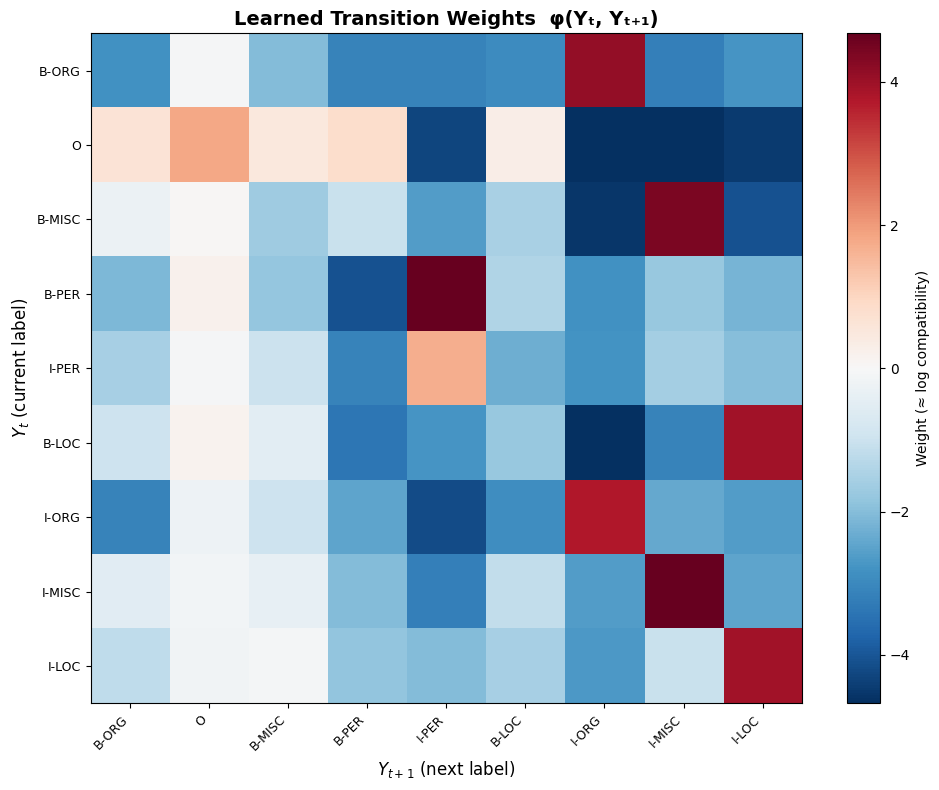

In [ ]:
# ============================================================
# Transition weight heatmap = pairwise factor φ(Yₜ, Yₜ₊₁)
# ============================================================
labels = list(crf_custom.classes_)
n = len(labels)
trans = np.zeros((n, n))

for (l1, l2), w in crf_custom.transition_features_.items():
    if l1 in labels and l2 in labels:
        i, j = labels.index(l1), labels.index(l2)
        trans[i][j] = w

fig, ax = plt.subplots(figsize=(10, 8))
vmax = np.percentile(np.abs(trans), 95)
im = ax.imshow(trans, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('$Y_{t+1}$ (next label)', fontsize=12)
ax.set_ylabel('$Y_t$ (current label)', fontsize=12)
ax.set_title('Learned Transition Weights  φ(Yₜ, Yₜ₊₁)', fontsize=14, fontweight='bold')

plt.colorbar(im, label='Weight (≈ log compatibility)')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Top learned state features (emission weights)
# ============================================================
state_features = crf_custom.state_features_
sorted_pos = sorted(state_features.items(), key=lambda x: x[1], reverse=True)
sorted_neg = sorted(state_features.items(), key=lambda x: x[1])

print("📊 Top-10 Positive State Features (feature supports this label):\n")
for (label_feat, weight) in sorted_pos[35000:35010]:
    label, feat = label_feat
    print(f"   {weight:+8.3f}  {label:12s} ← {feat}")

print(f"\n📊 Top-10 Negative State Features (feature opposes this label):\n")
for (label_feat, weight) in sorted_neg[10000:10010]:
    label, feat = label_feat
    print(f"   {weight:+8.3f}  {label:12s} ← {feat}")


📊 Top-10 Positive State Features (feature supports this label):

     +0.047  word[:2]:CO  ← B-LOC
     +0.047  word.lower():bochum ← I-ORG
     +0.047  word[:4]:Boch ← I-ORG
     +0.047  -3:word.lower():penalty ← B-ORG
     +0.047  word.lower():leipzig ← B-LOC
     +0.047  word[-3:]:zig ← B-LOC
     +0.047  word[-4:]:pzig ← B-LOC
     +0.047  word[:4]:Leip ← B-LOC
     +0.047  +2:word.lower():halle ← B-LOC
     +0.047  +3:word.lower():1,806 ← B-LOC

📊 Top-10 Negative State Features (feature opposes this label):

     +0.000  word[:3]:Leb ← I-LOC
     +0.000  +1:word.lower():live ← B-ORG
     +0.000  word[-4:]:alls ← I-LOC
     +0.000  +4:word.lower():higher ← O
     +0.000  -1:word.lower():mean ← B-LOC
     +0.000  -2:word.lower():mean ← I-LOC
     +0.000  +3:word.lower():fiscal ← B-LOC
     -0.000  +1:postag_bigram:JJ_" ← B-MISC
     +0.000  -2:word.lower():interest ← O
     +0.000  +4:word.lower():per ← B-ORG


### ✏️ [YOUR ANALYSIS] Feature Design and Results

---

**1) Feature description** — Describe each new feature you added:

| # | Feature Name | Design Rationale | Expected Effect (which entity types?) |
|---|---|---|---|
| 1 | word.shape | Captures capitalization and digit patterns (e.g., 'London' → 'Aaaaaa', '2024' → 'dddd') | PER, ORG (abbreviations) |
| 2-5 | Extended Affixes ([-4:], [:2~4]) | Identifies distinct English morphemes (prefixes/suffixes) like -land or Inter- that strongly correlate with proper nouns | ORG, LOC |
| 6-9 | Punctuation & Alphanumeric Flags | Captures compound/hyphenated nouns (New-York), acronyms (U.S.), filters symbolic tokens, and uses word length to distinguish entities | ORG, LOC, MISC, All |
| 10-11 | POS Bigrams (-1, +1 postag_bigram) | Captures surrounding syntactic patterns like 'Adjective + Noun' that commonly bracket entities, providing stronger boundary context | All (resolving B/I confusions) |
| 12-17 | Extended Context ±2 | Looks two words backward/forward to capture contextual triggers like 'Former President [NAME]' or succeeding verbs and positional titles | PER, ORG |
| 18 | isdigit_and_next_is_title | Helps identify cases like "1995 World Cup" where a number is directly part of an event name | MISC |
| 19 | sentence.is_headline | Flags if >50% of sentence is uppercase words, adjusting for contexts where normal istitle() rules fail | All (robustness in All-Caps sentences) |
| 20-31 | Wide Context Windows (±3, ±4) | Provides a broader view to capture strong semantic triggers (e.g., 'said', 'League') that are far from the entity token | All (resolving long-distance dependencies) |
---

**2) Error analysis** — Select at least 3 specific cases and analyze them:


- Case 1 (improved): 'CUTTITTA' | B-ORG → B-PER. All-cap person name. word-shape feature ('AAAAAAA') and maybe Headline Indicator is working.
- Case 2 (improved): 'Hassan' | I-PER → B-PER. Baseline model misclassified 'Defender Hassan Abbas' (O, B-PER, I-PER) -> (B-PER, I-PER, I-PER), but our model correct that Defender is Outside. Maybe postag_bigram feature is working. It give a information that NN-NNP on Defender.
- Case 3 (improved and still failing): 'Uzbekistan'. Sometimes it improved and sometimes it still fail. For improved case (B-ORG -> B-LOC), Extended Affix feature is working. But it is hard to figure out only Surface feature. It need semantic information like word embedding.
- Case 4 (degraded) : 'JAPAN' | B-LOC -> B-PER. Headline Indicator worked in the negative direction. All-caps context led the model to misclassify a country name as PER, despite JAPAN being correctly tagged as B-LOC in other sentences.

---

**3) Transition matrix interpretation** — Connect to Chapter 4 concepts:


- What patterns do you observe? (e.g., `B-PER → I-PER` has high weight, `B-PER → I-LOC` has very low weight)

In heatmap, red color (4~5) are
B-PER -> I-PER
B-ORG -> I-ORG
B-LOC -> I-LOC
I-MISC -> I-MISC

oragne color (2~3) are
O -> B-ORG
B-MISC -> I-MISC
I-ORG -> I-ORG

blue color (-5~-3) are
B- and I- transition.


- How does this relate to the *compatibility* concept from Section 4.1? Recall that in the Misconception example, the factor $\phi_1(A,B)$ assigns higher values to more compatible assignments.

compatibility function = factor (in undirected graph).
compatibility = How well the combination of variables fits together.
There are high probability that B-PER continue to I-PER. B- and I- transition has low proability. Because CRF sets (learn) transition weights as B-PER -> I-PER high, and B-/I- transition low.


- Do you see any transition patterns that surprise you?

Outside transition (O->X, X->O) is not overwhelming even though O tags are the most frequent. Because CRF use both node factors and edge factors together. So edge factor doesn't need  high outside transition weight because node factor can alreadly tell whether a word is O or not.


---

**4) Top feature weights** — Look at the top positive/negative state features:


- Which of YOUR new features appear in the top lists? What does their weight tell you?

+5.214  word[-3:]:day ← O
-2.573  word[-4:]:ased ← O
-2.074  word[-3:]:and ← B-PER

There are prefix/suffix feature.
If the word ended with 'day', it is likely to outside (e.g. Monday, today)
If the word ended with 'ased', it is not likely to outside.
If the word ended with 'and', it is not liekly to B-PER (Finland = LOC, not PER)

- Are there any features with near-zero weights? What does that imply about their usefulness?

+0.000  word[:3]:Leb ← I-LOC
+0.000  +1:word.lower():live ← B-ORG
+0.000  word[-4:]:alls ← I-LOC
+0.047  word[-3:]:zig ← B-LOC
-0.000  +1:postag_bigram:JJ_" ← B-MISC

Near-zero weights mean the feature doesn't provide enough evidence to help determine a word's tag.
It can happen in both rare and common situations, but most near-zero weight features here come from rare word-context combinations that the model didn't see enough during training

---

## 📢 Presentation Guide (5 min)

| Time | Content |
|------|---------|
| **1 min** | Introduce your key feature design ideas |
| **2 min** | Performance comparison: baseline vs. custom |
| **1 min** | 1–2 interesting error analysis cases |
| **1 min** | Lessons learned & connection to Chapter 4 |

> **Tip:** The depth of your *analysis* matters more than the absolute performance numbers.

---

## Grading Rubric

| Component | Points | Criteria |
|-----------|--------|----------|
| **Part 1: Baseline** | 50 | result analysis with thoughtful interpretation (25) |
| **Part 2: Feature Design** | 50 | ≥5 new features with rationale (20), performance analysis (15), error analysis & Ch.4 connection (15) |
| **Presentation** | +α | Clear communication, insightful analysis |

---

## Submission

- **Filename**: `Week5_NER_StudentID_Name.ipynb`
- Notebook must run **top-to-bottom without errors** (Restart & Run All)
- **Markdown analysis cells are the core of your grade** — don't leave them blank!
